# LIBRA BABY 1L Li2O Powder Bed


In [1]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from openmc_Li2O_powder import baby_model

**Li2O packed bed properties**
Pellet porosity: 0.0 %
Packing efficiency: 64.0 %
Pellet bed density: 1.2883399174578718 g/cm3
Oxygen mass fraction: 0.535466955938528 % mass
Lithium mass fraction: 0.464517584276673 % mass
Helium mass fraction: 1.545978479905476e-05 % mass


### Geometry

In [2]:
model = baby_model()
geometry = model.geometry

isotopes ['Al27', 'Ar36', 'Ar38', 'Ar40', 'B10', 'B11', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Si28', 'Si29', 'Si30', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'Zr90', 'Zr91', 'Zr92', 'Zr94', 'Zr96']
Searching libraries with the following priority {'ENDFB-8.0-NNDC': 1}
Isotopes found matching library requirements 556
Isotopes found matching particle requirements 1789
Isotopes found matching isotope requirements 313
Isotopes found matching all requirements 79
             library remote_file  \
1233  ENDFB-8.0-NNDC       H1.h5   
1234  ENDFB-8.0-NNDC       H2.h5   
1236  E

In [9]:
from openmc_Li2O_powder import (
    SS316L,
    Li2O_bed,
    SS304,
    heater_mat,
    furnace,
    alumina,
    lead,
    epoxy,
    he,
    air,
)
from libra_toolbox.neutronics.materials import Air, Concrete, Soil, IronConcrete, RicoRad, Copper

# Assign name to lead if it doesn't have one
if not lead.name:
    lead.name = "Lead"

# Define colors for materials
my_colors = {
    Air: "white",
    air: "white",
    SS316L: "slategray",
    Li2O_bed: "darkred",
    SS304: "dimgray",
    heater_mat: "firebrick",
    furnace: "darkorange",
    alumina: "mistyrose",
    lead: "black",
    epoxy: "cyan",
    he: "lightyellow",
    Concrete: "lightgrey",
    Soil: "saddlebrown",
    IronConcrete: "darkgrey",
    RicoRad: "forestgreen",
    Copper: "darkgoldenrod",
}

import matplotlib.patches as mpatches

def add_legend(ax):
    legend_elements = []
    seen_labels = set()
    for mat, color in my_colors.items():
        if color == "white":
            continue
        
        name = mat.name if mat.name else f"Material {mat.id}"
        if name in seen_labels:
            continue
        seen_labels.add(name)
        legend_elements.append(mpatches.Patch(facecolor=color, edgecolor="black", label=name))
    
    # Sort legend by name
    legend_elements.sort(key=lambda x: x.get_label())
    
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title="Material")

### Vault Geometry

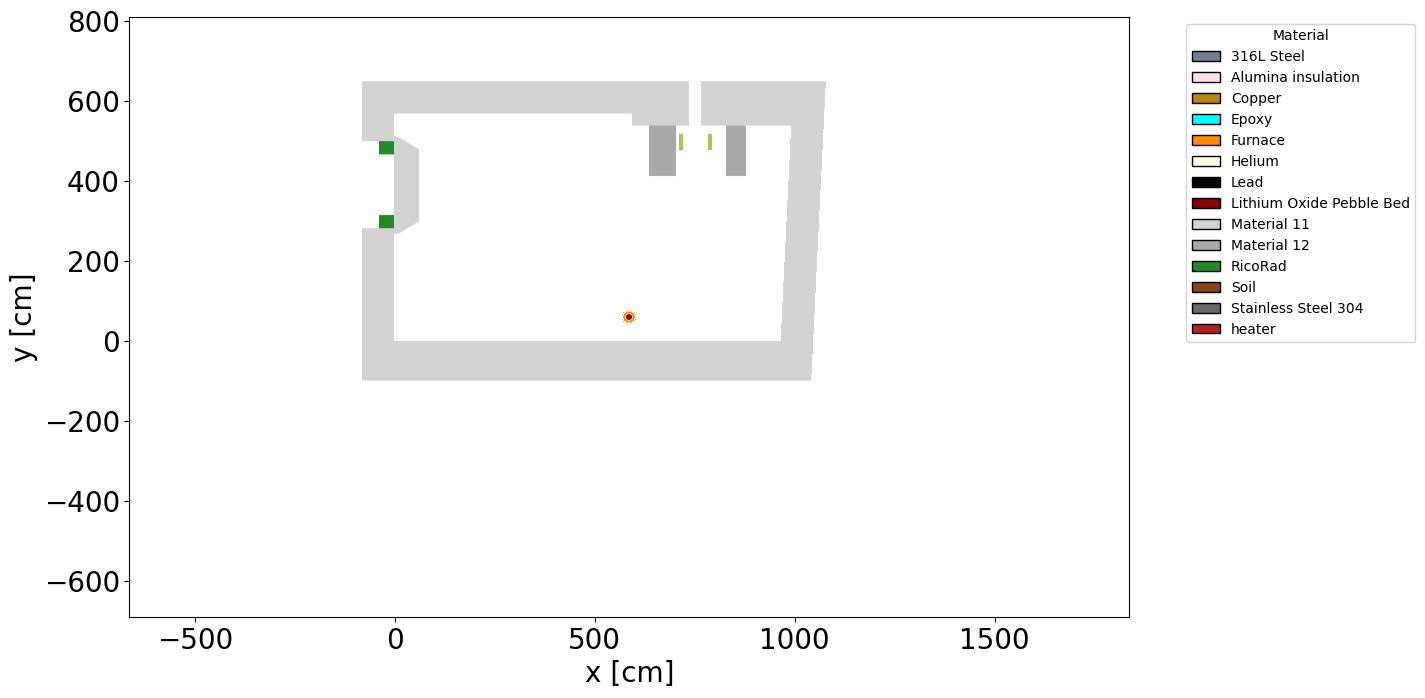

In [10]:
# Visualization

from libra_toolbox.neutronics.materials import Air
from openmc_Li2O_powder import air

x_c = 587
y_c = 60
z_c = 100
ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors=my_colors,
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
add_legend(ax)
plt.show()

### BABY 1L Geometry Views

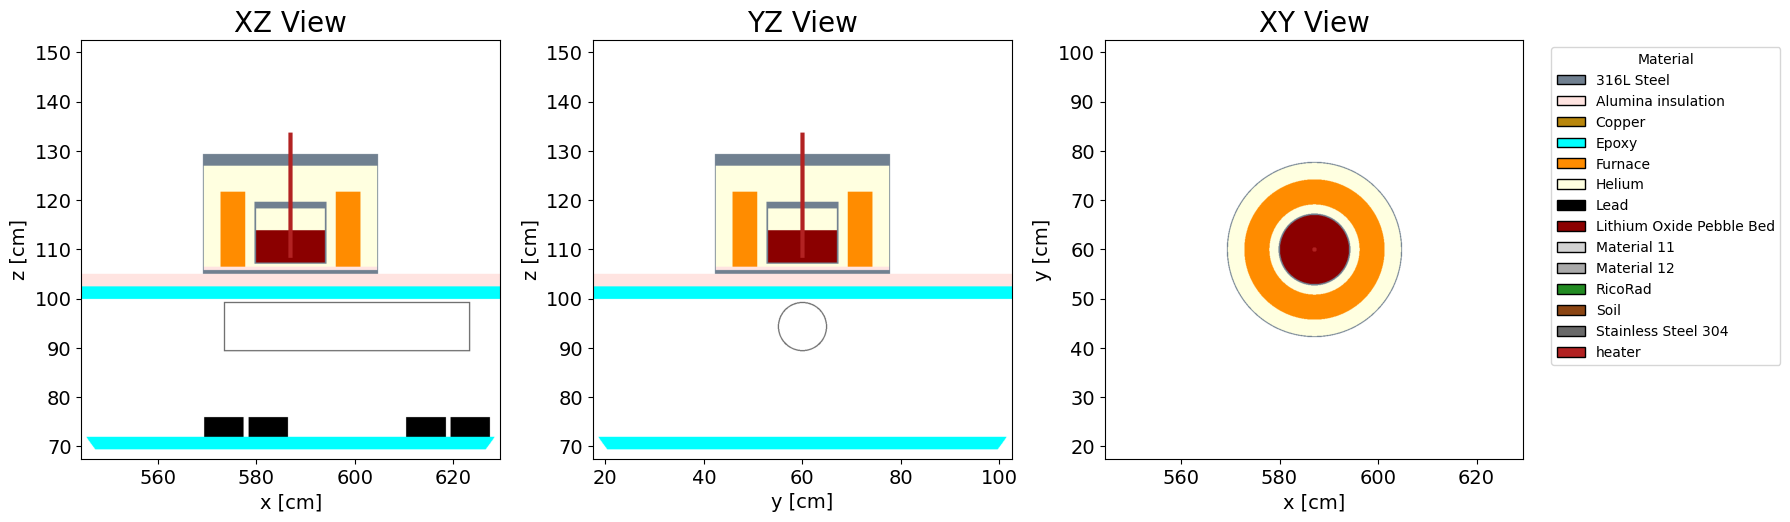

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# XZ View
geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xz",
    color_by="material",
    colors=my_colors,
    axes=ax1
)
ax1.set_title("XZ View", fontsize=20)
ax1.tick_params(axis="both", labelsize=14)
ax1.set_xlabel("x [cm]", fontsize=14)
ax1.set_ylabel("z [cm]", fontsize=14)

# YZ View
geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="yz",
    color_by="material",
    colors=my_colors,
    axes=ax2
)
ax2.set_title("YZ View", fontsize=20)
ax2.tick_params(axis="both", labelsize=14)
ax2.set_xlabel("y [cm]", fontsize=14)
ax2.set_ylabel("z [cm]", fontsize=14)

# XY View
geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors=my_colors,
    axes=ax3
)
ax3.set_title("XY View", fontsize=20)
ax3.tick_params(axis="both", labelsize=14)
ax3.set_xlabel("x [cm]", fontsize=14)
ax3.set_ylabel("y [cm]", fontsize=14)

add_legend(ax3)
plt.tight_layout()
plt.show()

### Spatial Distribution Results

<class 'openmc.mesh.CylindricalMesh'>
Mesh tally data exported to results/tally_mesh_data_Li2O_powder.vtk


/home/vk9746/miniforge3/envs/BABY_Li2O/lib/python3.12/site-packages/openmc/mesh.py:1952: UserWarning: Cartesian coordinates are returned from this property as of version 0.14.0
  warnings.warn('Cartesian coordinates are returned from this property as of version 0.14.0')
/tmp/ipykernel_14661/1011522648.py:69: RuntimeWarning: invalid value encountered in divide
  rel_std_dev_array = stdev_array_combined / mean_array_summed


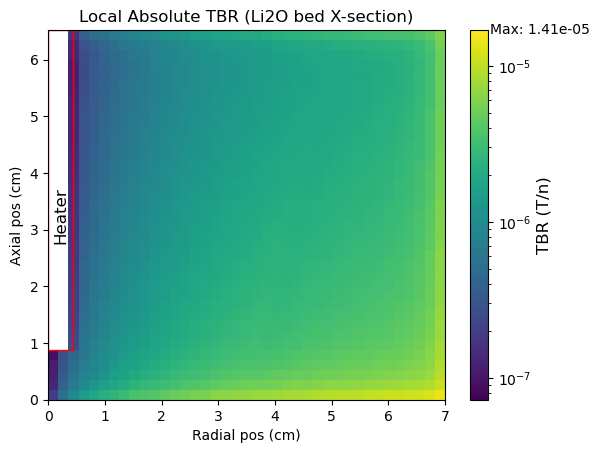

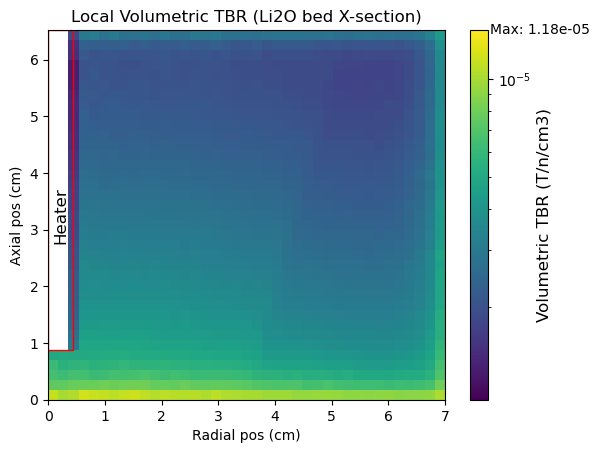

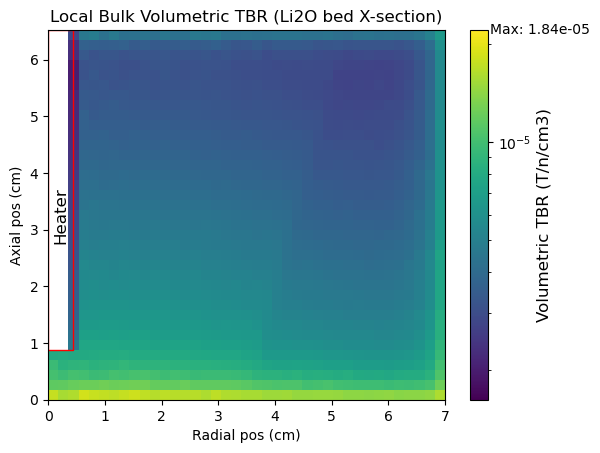

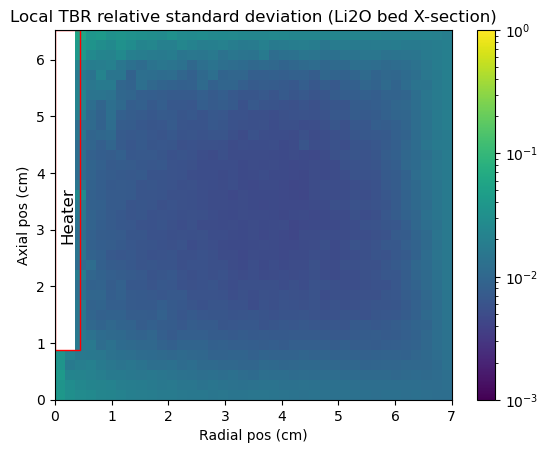

In [18]:
from openmc_Li2O_powder import Li2O_bed_radius, Li2O_bed_thickness, heater_gap, heater_radius, packing_efficiency, mesh, pellet_porosity
# Load the statepoint file
sp = openmc.StatePoint("results/LiOx_powder_results.h5")

if mesh == 1:
    import matplotlib.colors as mcolors
    import matplotlib.patches as patches
    # import vtk

    # Get the tally object from the statepoint file
    tally_mesh = sp.get_tally(name="TBR_mesh")

    # Get pandas dataframe for the cell tally data
    df = tally_mesh.get_pandas_dataframe()

    # Get the mesh object from the tally filters
    mesh = None
    for f in tally_mesh.filters:
        if isinstance(f, openmc.MeshFilter):
            mesh = f.mesh
            print(type(mesh))
            break

    if mesh is None:
        raise ValueError("No mesh filter found in the tally!")

    if mesh is not None:

        # Extract the number of bins for each dimension from the mesh
        n_r = len(mesh.r_grid) - 1  # Radial bins
        n_phi = len(mesh.phi_grid) - 1  # Angular binss
        n_z = len(mesh.z_grid) - 1  # Axial bins

        # Convert mean TBR values to NumPy array
        mean_array = df['mean'].values.reshape((n_z, n_phi, n_r))

        # Convert std dev values to NumPy array
        stdev_array = df['std. dev.'].values.reshape((n_z, n_phi, n_r))

        ### Export vtk of mesh results ###
        datasets = {
            "mean_vol_TBR": mean_array.transpose(2, 1, 0),
            "mean_bulk_vol_TBR": (mean_array / packing_efficiency).transpose(2, 1, 0),
        }
        mesh.write_data_to_vtk("results/tally_mesh_data_Li2O_powder.vtk", datasets, volume_normalization=True) # True = use built-in data normalisation

        print("Mesh tally data exported to results/tally_mesh_data_Li2O_powder.vtk")

        # Reshape the mean and standard deviation arrays to 2D for plotting by collapsing angular bins
        # Combine the standard deviation over angular bins when collapsing the angular dimension
        stdev_array_combined = np.sqrt(np.sum(stdev_array**2, axis=1))

        # Get the cell volumes from the mesh object
        mesh_volumes = mesh.volumes
        # Sum all angular bins for each r and z bin
        mean_array_summed = np.sum(mean_array, axis=1)
        volume_array_summed = np.sum(mesh_volumes, axis=1)

        # Reshape cell volumes to match the shape of the tally data
        volume_array_summed = np.squeeze(volume_array_summed).transpose()

        # Calculate volumetric TBR by dividing mean TBR by cell volumes
        vol_tbr_array = mean_array_summed / volume_array_summed

        # Calculate TBR in bulk Li2O by dividing volumetric TBR by packing efficiency
        bulk_vol_tbr_array = vol_tbr_array / (packing_efficiency * (1 - pellet_porosity))

        # Divide the standard deviation values by the mean values to get the relative standard deviation for plotting below
        rel_std_dev_array = stdev_array_combined / mean_array_summed

        #### Plot local TBR values ####

        fig, ax = plt.subplots()
    
        im = ax.imshow(
            mean_array_summed,
            interpolation='nearest',
            extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
            origin='lower',
            aspect='auto',
            norm=mcolors.LogNorm(vmin=(np.min(mean_array_summed[mean_array_summed > 0])*0.8), vmax=(np.max(mean_array_summed))*1.2),  # Use LogNorm for logarithmic scale
            cmap='viridis'  # You can change the colormap if desired
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('TBR (T/n)', fontsize=12)
        cbar.ax.text(1.1, 1.0, f"Max: {np.max(mean_array_summed):.2e}", transform=cbar.ax.transAxes, ha='left', va='center')
        ax.set_title('Local Absolute TBR (Li2O bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')


        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

        #### Plot local volumetric TBR ####
        
        fig, ax = plt.subplots()
    
        im = ax.imshow(
            vol_tbr_array,
            interpolation='nearest',
            extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
            origin='lower',
            aspect='auto',
            norm=mcolors.LogNorm(vmin=(np.min(vol_tbr_array[vol_tbr_array > 0]))*0.8, vmax=(np.max(vol_tbr_array))*1.2),  # Use LogNorm for logarithmic scale
            cmap='viridis'  # You can change the colormap if desired
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Volumetric TBR (T/n/cm3)', fontsize=12)
        cbar.ax.text(1.1, 1.0, f"Max: {np.max(vol_tbr_array):.2e}", transform=cbar.ax.transAxes, ha='left', va='center')
        ax.set_title('Local Volumetric TBR (Li2O bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')


        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

        #### Plot local bulk volumetric TBR ####
        
        fig, ax = plt.subplots()
    
        im = ax.imshow(
            bulk_vol_tbr_array,
            interpolation='nearest',
            extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
            origin='lower',
            aspect='auto',
            norm=mcolors.LogNorm(vmin=(np.min(bulk_vol_tbr_array[vol_tbr_array > 0]))*0.8, vmax=(np.max(bulk_vol_tbr_array))*1.2),  # Use LogNorm for logarithmic scale
            cmap='viridis'  # You can change the colormap if desired
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Volumetric TBR (T/n/cm3)', fontsize=12)
        cbar.ax.text(1.1, 1.0, f"Max: {np.max(bulk_vol_tbr_array):.2e}", transform=cbar.ax.transAxes, ha='left', va='center')
        ax.set_title('Local Bulk Volumetric TBR (Li2O bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')


        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

        #### Plot local TBR relative standard deviation values ####

        fig, ax = plt.subplots()

        im = ax.imshow(
        rel_std_dev_array,
        interpolation='nearest',
        extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
        origin='lower',
        aspect='auto',
        norm=mcolors.LogNorm(vmin=1e-3, vmax=1),  # Use LogNorm for logarithmic scale
        cmap='viridis'
        )
        
        cbar = plt.colorbar(im, ax=ax)
        ax.set_title('Local TBR relative standard deviation (Li2O bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')

        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

### Global TBR Results

In [14]:
tally_obj = sp.get_tally(name="TBR")

# Access underlying numpy arrays directly to avoid pandas error
mean = tally_obj.mean.ravel()[0]
stdev = tally_obj.std_dev.ravel()[0]

# Print the global TBR results
print(f"Global TBR: {mean:.6e}")
print(f"Global TBR Standard Deviation: {stdev:.6e}")

rel_stdev = stdev / mean

print(f"Relative standard deviation: {rel_stdev:.6e}\n")
print("Relative standard deviation below 1e-02 (1%) indicates good convergence.")

Global TBR: 3.198939e-03
Global TBR Standard Deviation: 3.297981e-06
Relative standard deviation: 1.030961e-03

Relative standard deviation below 1e-02 (1%) indicates good convergence.
